In [1]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

In [2]:
with open('/home/annierosen16/master.pkl', 'rb') as f:
    
    master = pickle.load(f)

In [5]:
with open('/home/annierosen16/pressure.pkl', 'rb') as f:
    
    pressure = pickle.load(f)
    
with open('/home/annierosen16/sgp_latitudes.pkl', 'rb') as f:
    
    latitude = pickle.load(f)
    
with open('/home/annierosen16/sgp_longitudes.pkl', 'rb') as f:
    
    longitude = pickle.load(f)

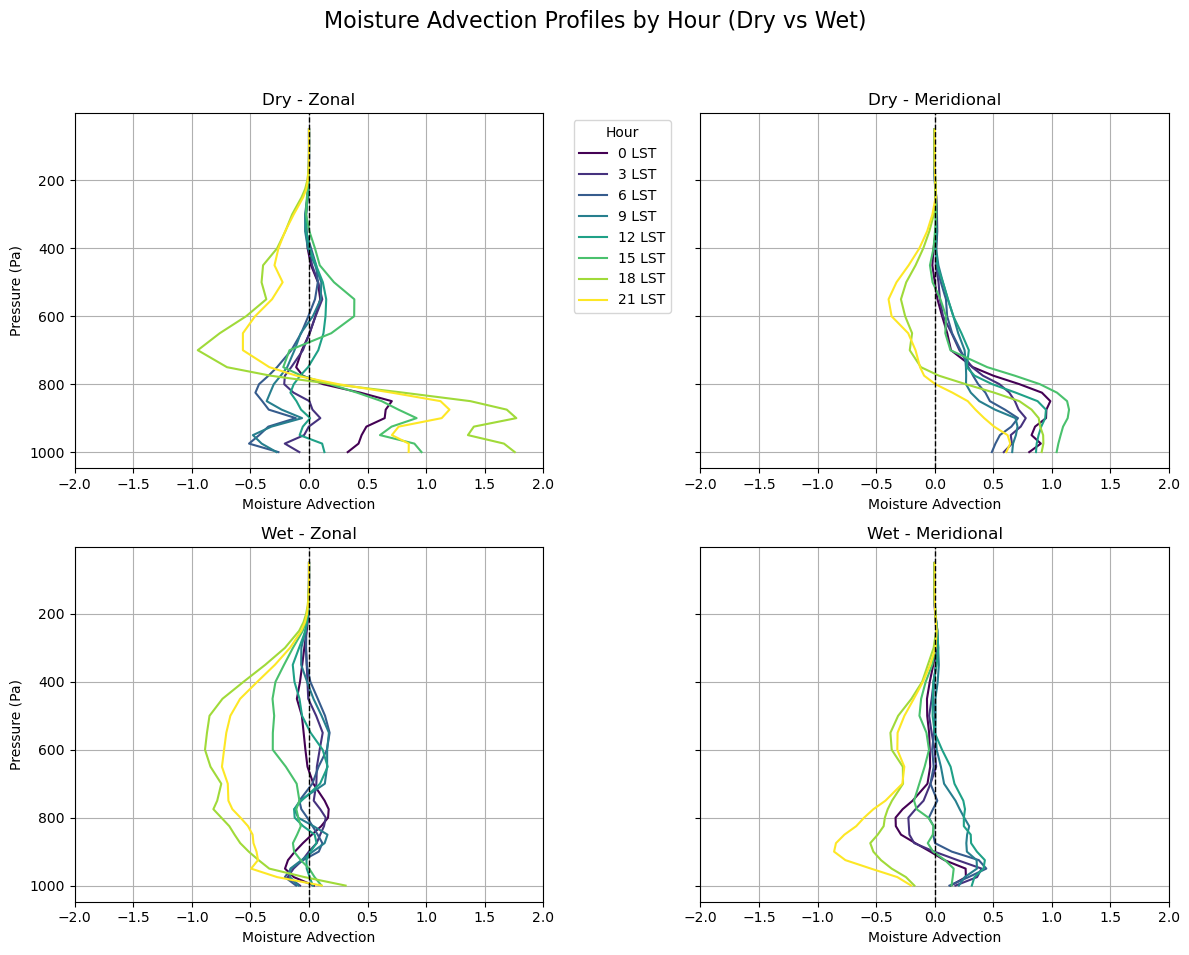

In [4]:
home_dir = os.path.expanduser("~")

# Load .pkl files
zonal_files = glob.glob(os.path.join(home_dir, "*lst_zonal_advection_profile.pkl"))

meridional_files = glob.glob(os.path.join(home_dir, "*lst_meridional_advection_profile.pkl"))

# Get hour labels and sort numerically
hours = sorted([os.path.basename(f).split("lst")[0] for f in zonal_files], key=lambda x: int(x))

# load profiles into dictionaries
zonal_data = {os.path.basename(f).split("lst")[0]: pickle.load(open(f, 'rb')) for f in zonal_files}

meridional_data = {os.path.basename(f).split("lst")[0]: pickle.load(open(f, 'rb')) for f in meridional_files}

# Define colors for each hour
colors = plt.cm.viridis(np.linspace(0, 1, len(hours)))

# Create 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

axs = axs.flatten()

titles = [
    "Dry - Zonal", "Dry - Meridional",
    "Wet - Zonal", "Wet - Meridional"
]

# Plotting
for i, hour in enumerate(hours):
    
    color = colors[i]
    
    zonal_dry = zonal_data[hour][f"{hour}lst_dry"]
    
    merid_dry = meridional_data[hour][f"{hour}lst_dry"]
    
    zonal_wet = zonal_data[hour][f"{hour}lst_wet"]
    
    merid_wet = meridional_data[hour][f"{hour}lst_wet"]

    axs[0].plot(zonal_dry, pressure, color=color, label=f"{hour} LST")
    
    axs[1].plot(merid_dry, pressure, color=color)
    
    axs[2].plot(zonal_wet, pressure, color=color)
    
    axs[3].plot(merid_wet, pressure, color=color)

# Style each subplot
for ax, title in zip(axs, titles):
    
    ax.set_title(title)
    
    ax.set_xlim(-2, 2)
    
    ax.set_xlabel("Moisture Advection")
    
    ax.grid(True)
    
    ax.invert_yaxis()
    
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)

axs[0].set_ylabel("Pressure (Pa)")

axs[2].set_ylabel("Pressure (Pa)")

axs[0].legend(title="Hour", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle("Moisture Advection Profiles by Hour (Dry vs Wet)", fontsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.gca().invert_yaxis()

plt.show()

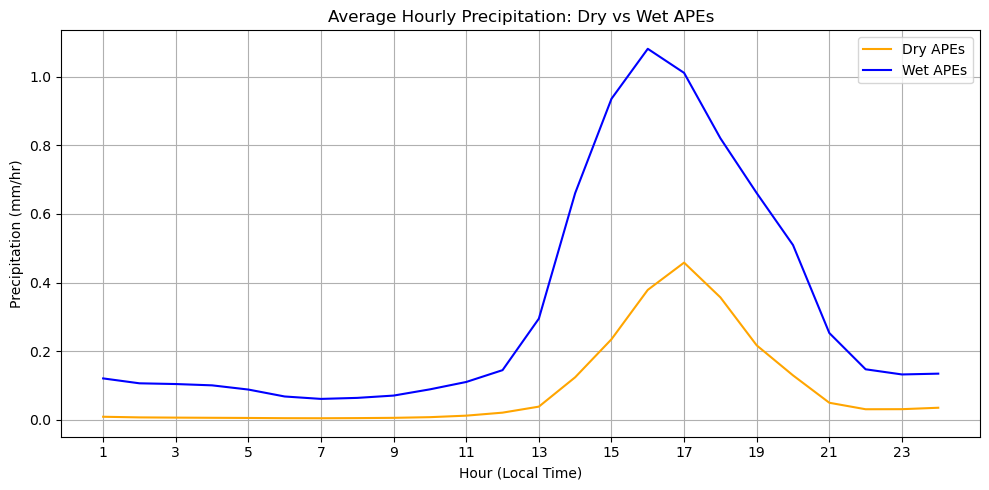

In [5]:
dry_case = master[master['dryape']==True]

wet_case = master[master['wetape']==True]

# Stack daily_precip arrays and compute the hourly average

dry_mean = np.vstack(dry_case['daily_precip'].values).mean(axis=0)

wet_mean = np.vstack(wet_case['daily_precip'].values).mean(axis=0)

# X-axis: hours 1 to 24 (if your arrays are labeled that way)
hours = np.arange(1, 25)

# Plot
plt.figure(figsize=(10, 5))

plt.plot(hours, dry_mean, label='Dry APEs', color='orange')

plt.plot(hours, wet_mean, label='Wet APEs', color='blue')

plt.xlabel('Hour (Local Time)')

plt.ylabel('Precipitation (mm/hr)')

plt.title('Average Hourly Precipitation: Dry vs Wet APEs')

plt.legend()

plt.grid(True)

plt.xticks(np.arange(1, 25, 2))  # every 2 hours

plt.tight_layout()

plt.show()


In [6]:
# reading in ERA5 u, v, w and q

base_path = '/data/rong4/Data/ERA5/3hourly/quvw_US'

years = [str(year) for year in range(2001, 2019)]

def get_files(folder, component):

    files = glob.glob(os.path.join(base_path, folder, f"era5.{component}.*.nc"))

    filtered_files = [f for f in files if any(year in f for year in years)]
    
    return filtered_files

# Get the files for each component

u_files = get_files('u_component_of_wind', 'u_component_of_wind')

v_files = get_files('v_component_of_wind', 'v_component_of_wind')

w_files = get_files('vertical_velocity', 'vertical_velocity')

q_files = get_files('specific_humidity', 'specific_humidity')

all_files = u_files + v_files + q_files + w_files

# open all datasets at once

advections = xr.open_mfdataset(all_files, combine='by_coords', chunks={'time': 24})

In [7]:
# filtering for correct domain and time

advvars = advections.sel(
    
    latitude=slice(40, 29),
    
    longitude=slice(-106, -94)
)

advvars['time'] = advvars['time'] - pd.Timedelta(hours=6)

sub = advvars.where(
    
    (advvars.time.dt.hour.isin([0, 6, 12])) &
    
    (advvars.time.dt.month.isin([5, 6, 7, 8, 9])) &
    
    (advvars.time.dt.year.isin(range(2001, 2019))),
    
    drop=True
)

# Resample to daily frequency and compute the mean

daily_avg = sub.resample(time='D').mean().dropna(dim='time', how='all')

daily_avg['time'].shape

(2754,)

In [8]:
## reading in surface pressure 

# ERA5 information: surface pressure

sfc_pressure_path = '/data/rong4/Data/ERA5/3hourly/quvw_US/surface_pressure'

all_files = glob.glob(os.path.join(sfc_pressure_path, "era5.surface_pressure.*.nc"))

# Filter files for years 2001-2018 and months 5-9

filtered_files = [
    
    file for file in all_files 
    
    if 2001 <= int(os.path.basename(file).split(".")[2][:4]) <= 2018  
    
    and 5 <= int(os.path.basename(file).split(".")[2][4:]) <= 9       
]

all_sfc_p = xr.open_mfdataset(filtered_files, combine='by_coords')

all_sfc_p = all_sfc_p.sel(latitude=slice(39.0, 30.0), longitude=slice(-105.0, -95.0))

sfcp = all_sfc_p.assign_coords(time=all_sfc_p.time - pd.Timedelta(hours=6))

sfcp = sfcp.sel(time=sfcp.time[sfcp.time.dt.hour == 6])

print(sfcp['time'].shape)

# average surface pressure per gridpoint

spdf = sfcp['sp'].to_dataframe().reset_index()

spdf_mean = spdf.groupby(['latitude', 'longitude'])['sp'].mean().reset_index(name='average_sp')

(2754,)


In [9]:
# def calculate_horizontal_advection(u, v, q, lat, lon):

#     R = 6371000  # radius of Earth (meters)
    
#     rho_water = 1000 # kg/m^3
    
#     seconds_to_day = 60 * 60 * 24 # to convert from s --> day

#     latitude_range = np.sin(np.radians(lat[-1])) - np.sin(np.radians(lat[0]))
    
#     longitude_range = np.radians(lon[-1]) - np.radians(lon[0])
    
#     lon_grid, lat_grid = np.meshgrid(np.radians(lon), np.radians(lat))
    
#     delta_y = np.radians(lat[1]) - np.radians(lat[0])

#     delta_x = np.radians(lon[1]) - np.radians(lon[0])
    
#     # shaped as (#lons, #lats) so first row represents all values for first latitude (eg: 30,30,30...)
#     cos_correction = np.cos(lat_grid)
    
#     dqdx = np.zeros_like(q)
#     dqdy = np.zeros_like(q)
    
#     # Loop through each pressure level
    
#     for k in range(u.shape[0]):
        
#         # Central points
    
#         dqdx[k, :, 1:-1] = (q[k, :, 2:] - q[k, :, :-2]) / (2 * delta_x)
#         dqdy[k, 1:-1, :] = (q[k, 2:, :] - q[k, :-2, :]) / (2 * delta_y)
        
#         # Left and right boundaries (x-direction)
        
#         dqdx[k, :, 0] = (q[k, :, 1] - q[k, :, 0]) / (delta_x)
#         dqdx[k, :, -1] = (q[k, :, -2] - q[k, :, -1]) / (delta_x)

#         # Top and bottom boundaries (y-direction)
        
#         dqdy[k, 0, :] = (q[k, 1, :] - q[k, 0, :]) / (delta_y)
#         dqdy[k, -1, :] = (q[k, -2, :] - q[k, -1, :]) / (delta_y)
        
#         dx = R * cos_correction * delta_x
#         dy = R * delta_y

#         # for every grid point, multiply by the area extent of that grid box 
        
#         dqdy[k] = (1/R) * dqdy[k] * dx * dy
        
#         dqdx[k] = (1/(R*cos_correction)) * dqdx[k] * dx * dy
        
#     meridional_advection = -(v * dqdy)
    
#     zonal_advection = -(u * dqdx)
    
#     total_area = []
    
#     for i in dx: 
        
#         total_area.append(i*dy)
        
#     A = np.sum(total_area)
    
#     # Area weighted average
#     zonal_advection_area_weighted = np.sum(zonal_advection, axis=(1,2))*(1/A)*seconds_to_day*rho_water
    
#     meridional_advection_area_weighted = np.sum(meridional_advection, axis=(1,2))*(1/A)*seconds_to_day*rho_water

#     # Units = 10^-3/day 
#     # Shapes returned: (#pressure levels) because advection is averaged over the domain for every level 
    
#     return zonal_advection_area_weighted, meridional_advection_area_weighted

In [10]:
def calculate_horizontal_advection_new(u, v, q, lat, lon):

    R = 6371000  # Earth's radius in meters
    
    seconds_to_day = 60 * 60 * 24  # convert from seconds to days

    # Convert lat/lon to radians
    lat_rad = np.radians(lat)  # φ (phi) — latitude
    
    lon_rad = np.radians(lon)  # θ (theta) — longitude

    # Grid spacing in radians
    dphi = lat_rad[1] - lat_rad[0]     # meridional spacing (north-south)
    
    dtheta = lon_rad[1] - lon_rad[0]   # zonal spacing (east-west)

    # Create 2D meshgrid of lat/lon in radians
    lon_grid, lat_grid = np.meshgrid(lon_rad, lat_rad)
    
    # Grid cell dimensions
    dx = R * dtheta * np.cos(lat_grid)   # zonal grid spacing (varies with latitude)
    
    dy = R * dphi                        # meridional spacing (constant)

    # Area of each grid cell
    grid_area = dx * dy  # shape: (lat, lon)
    
    # Initialize gradients of q
    dq_dtheta = np.zeros_like(q)  # zonal derivative ∂q/∂θ
    
    dq_dphi = np.zeros_like(q)    # meridional derivative ∂q/∂φ

    # Loop through each pressure level
    for k in range(q.shape[0]):
        # Zonal derivative (x-direction, longitude)
        dq_dtheta[k, :, 1:-1] = (q[k, :, 2:] - q[k, :, :-2]) / (2 * dtheta)
        
        dq_dtheta[k, :, 0] = (q[k, :, 1] - q[k, :, 0]) / dtheta
        
        dq_dtheta[k, :, -1] = (q[k, :, -2] - q[k, :, -1]) / dtheta

        # Meridional derivative (y-direction, latitude)
        
        dq_dphi[k, 1:-1, :] = (q[k, 2:, :] - q[k, :-2, :]) / (2 * dphi)
        
        dq_dphi[k, 0, :] = (q[k, 1, :] - q[k, 0, :]) / dphi
        
        dq_dphi[k, -1, :] = (q[k, -2, :] - q[k, -1, :]) / dphi

    # Compute advection terms using spherical coordinates
    # Note: sin(lat) and cos(lat) come from geometry of spherical Earth
    
    zonal_advection = -(u * dq_dtheta) / (R * np.cos(lat_grid))
    
    meridional_advection = -(v * dq_dphi) / (R)

    # Multiply by grid area to get total contribution
    weighted_zonal = zonal_advection * grid_area
    
    weighted_meridional = meridional_advection * grid_area
    
    # Total area of the domain
    A = np.sum(grid_area)

    # Area-weighted average for each pressure level
    zonal_adv_avg = np.sum(weighted_zonal, axis=(1, 2)) / A * seconds_to_day
    
    meridional_adv_avg = np.sum(weighted_meridional, axis=(1, 2)) / A * seconds_to_day

    return zonal_adv_avg, meridional_adv_avg


In [11]:
# def calculate_dqdy(v, q, lat, lon):

#     R = 6371000  # radius of Earth (meters)
    
#     rho_water = 1000 # kg/m^3
    
#     seconds_to_day = 60 * 60 * 24 # to convert from s --> day

#     latitude_range = np.sin(np.radians(lat[-1])) - np.sin(np.radians(lat[0]))
    
#     longitude_range = np.radians(lon[-1]) - np.radians(lon[0])
    
#     lon_grid, lat_grid = np.meshgrid(np.radians(lon), np.radians(lat))
    
#     delta_y = np.radians(lat[1]) - np.radians(lat[0])

#     delta_x = np.radians(lon[1]) - np.radians(lon[0])
    
#     # shaped as (#lons, #lats) so first row represents all values for first latitude (eg: 30,30,30...)
#     cos_correction = np.cos(lat_grid)
    
#     dqdx = np.zeros_like(q)
#     dqdy = np.zeros_like(q)
    
#     # Loop through each pressure level
    
#     for k in range(v.shape[0]):
        
#         # Central points
    
#         dqdx[k, :, 1:-1] = (q[k, :, 2:] - q[k, :, :-2]) / (2 * delta_x)
#         dqdy[k, 1:-1, :] = (q[k, 2:, :] - q[k, :-2, :]) / (2 * delta_y)
        
#         # Left and right boundaries (x-direction)
        
#         dqdx[k, :, 0] = (q[k, :, 1] - q[k, :, 0]) / (delta_x)
#         dqdx[k, :, -1] = (q[k, :, -2] - q[k, :, -1]) / (delta_x)

#         # Top and bottom boundaries (y-direction)
        
#         dqdy[k, 0, :] = (q[k, 1, :] - q[k, 0, :]) / (delta_y)
#         dqdy[k, -1, :] = (q[k, -2, :] - q[k, -1, :]) / (delta_y)
        
#         dx = R * cos_correction * delta_x
#         dy = R * delta_y

#         # for every grid point, multiply by the area extent of that grid box 
        
#         dqdy[k] = (1/R) * dqdy[k] * dx * dy
        
#         dqdx[k] = (1/(R*cos_correction)) * dqdx[k] * dx * dy
        
#     dqdy_domain_mean = np.mean(dqdy, axis=(1, 2))  
    
#     return dqdy_domain_mean

In [12]:
# def calculate_vertical_advection(w, q, pressure, lat, lon):
#     """
#     Calculate vertical advection of specific humidity over a domain without flipping the pressure array.
    
#     Args:
#         w (ndarray): Vertical velocity (Pa/s), shape = (levels, lat, lon).
#         q (ndarray): Specific humidity (kg/kg), shape = (levels, lat, lon).
#         pressure (ndarray): Pressure levels (Pa), shape = (levels,).
#         lat (ndarray): Latitude values (degrees), shape = (lat,).
#         lon (ndarray): Longitude values (degrees), shape = (lon,).
    
#     Returns:
#         vertical_advection_area_weighted (ndarray): Area-weighted vertical advection (10^3/day),
#                                                     shape = (levels,).
#     """
    
#     R = 6371000  # radius of Earth (meters)
    
#     rho_water = 1000  # kg/m^3
    
#     seconds_to_day = 60 * 60 * 24  # to convert from s --> day

#     # Grid spacing and corrections
#     delta_y = np.radians(lat[1]) - np.radians(lat[0])
    
#     delta_x = np.radians(lon[1]) - np.radians(lon[0])
    
#     lon_grid, lat_grid = np.meshgrid(np.radians(lon), np.radians(lat))
    
#     cos_correction = np.cos(lat_grid)

#     dx = R * cos_correction * delta_x  # Zonal grid spacing in meters
    
#     dy = R * delta_y                   # Meridional grid spacing in meters
    
#     grid_area = dx * dy                # Area of each grid cell (lat, lon)
    
#     total_area = np.sum(grid_area)     # Total domain area
        
#     # Initialize the vertical gradient array
#     dqdp = np.zeros_like(q)

#     # Compute vertical gradient of specific humidity (dq/dp)
#     for j in range(1, q.shape[0] - 1):  # Central differencing for interior levels
        
#         dqdp[j, :, :] = (q[j - 1, :, :] - q[j + 1, :, :]) / (pressure[j - 1] - pressure[j + 1])

#     # Forward/backward differencing for boundaries
#     dqdp[0, :, :] = (q[0, :, :] - q[1, :, :]) / (pressure[0] - pressure[1])
    
#     dqdp[-1, :, :] = (q[-2, :, :] - q[-1, :, :]) / (pressure[-2] - pressure[-1])

#     # Vertical advection term: -omega * dq/dp
#     vertical_advection = -(w * dqdp)  # Shape = (levels, lat, lon)
    
#     # Area-weighted average across the domain for each pressure level
#     vertical_advection_area_weighted = np.sum(vertical_advection * grid_area, axis=(1, 2)) / total_area

#     # Convert to mm/day
#     vertical_advection_area_weighted *= seconds_to_day * rho_water  

#     return vertical_advection_area_weighted

In [13]:
def calculate_vertical_advection_new(w, q, pressure, lat, lon):
    
    R = 6371000  # radius of Earth (meters)
    
    rho_water = 1000  # kg/m^3
    
    seconds_to_day = 60 * 60 * 24  # to convert from s --> day

    # Grid spacing and corrections
    dphi = np.radians(lat[1]) - np.radians(lat[0])
    
    dtheta = np.radians(lon[1]) - np.radians(lon[0])
    
    lon_grid, lat_grid = np.meshgrid(np.radians(lon), np.radians(lat))

    dx = R * dtheta * np.cos(lat_grid)  
    
    dy = R * dphi                   
    
    grid_area = dx * dy                # Area of each grid cell (lat, lon)
        
    # Initialize the vertical gradient array
    dq_dp = np.zeros_like(q)

    # Compute vertical gradient of specific humidity (dq/dp)
    for j in range(1, q.shape[0] - 1):  # Central differencing for interior levels
        
        dq_dp[j, :, :] = (q[j - 1, :, :] - q[j + 1, :, :]) / (pressure[j - 1] - pressure[j + 1])

    # Forward/backward differencing for boundaries
    dq_dp[0, :, :] = (q[0, :, :] - q[1, :, :]) / (pressure[0] - pressure[1])
    
    dq_dp[-1, :, :] = (q[-2, :, :] - q[-1, :, :]) / (pressure[-2] - pressure[-1])

    # Vertical advection term: -omega * dq/dp
    vertical_advection = -(w * dq_dp)  # Shape = (levels, lat, lon)
    
    A = np.sum(grid_area)
    
    # Area-weighted average across the domain for each pressure level
    vertical_advection_area_weighted = np.sum(vertical_advection * grid_area, axis=(1, 2)) / A

    # Convert to mm/day
    vertical_advection_area_weighted *= seconds_to_day   

    return vertical_advection_area_weighted

In [14]:
# array = (time = 12 LST, levels, latitude, longitude)

# reversing latitude to be increasing, pressure should go top to bottom 

u = daily_avg['u'].load().data[:, :, ::-1, :]

print("u loaded")

v = daily_avg['v'].load().data[:, :, ::-1, :]

print("v loaded")

q = daily_avg['q'].load().data[:, :, ::-1, :] 

print("q loaded")

w = daily_avg['w'].load().data[:, :, ::-1, :] 

print("w loaded")

latitude = daily_avg['latitude'].data[::-1]

longitude = daily_avg['longitude'].data

pressure = daily_avg['level'].data * 100 # pressure needs to be Pa for advection calculation

u loaded
v loaded
q loaded
w loaded


#### extracting dqdy

In [15]:
# # Ensure columns exist in master for storing advection profiles

# master['dqdy_domain_mean'] = None

# for date in range(master.shape[0]):

#     target_date = master['date'].iloc[date]  

#     target_date = np.datetime64(target_date)

#     # Find the index in daily_avg['time'].data

#     date_idx = np.where(daily_avg['time'].data == target_date)[0][0]

#     lat_idx = master['latitude'].iloc[date]

#     lon_idx = master['longitude'].iloc[date]

#     # Define the center point and half-window (in degrees)

#     delta = 0.5

#     lat_mask = (latitude >= (lat_idx - delta)) & (latitude <= (lat_idx + delta))

#     lon_mask = (longitude >= (lon_idx - delta)) & (longitude <= (lon_idx + delta))

#     lat_indices = np.where(lat_mask)[0]

#     lon_indices = np.where(lon_mask)[0]

#     lat_mini = latitude[lat_indices]

#     lon_mini = longitude[lon_indices]

#     # Extract mini domains for u, v, q, w

#     v_mini = v[date_idx, :, :, :][:, lat_mask, :][:, :, lon_mask]

#     q_mini = q[date_idx, :, :, :][:, lat_mask, :][:, :, lon_mask]

#     # Compute advection

#     dqdy = calculate_dqdy(v_mini, q_mini, lat_mini, lon_mini)

#     # Assign results to the DataFrame

#     master.at[date, 'dqdy_domain_mean'] = dqdy

In [ ]:
# dryapes = master[master['dryape']==True].reset_index(drop=True)

# wetapes = master[master['wetape']==True].reset_index(drop=True)

In [ ]:
# master_with_dqdy = master[['date','latitude','longitude','dqdy_domain_mean']]

# with open("master_with_dqdy.pkl", "wb") as file:
    
#     pickle.dump(master_with_dqdy, file)

### applying to APEs vs. non-APEs to check that vertical profiles make sense

In [16]:
# Ensure columns exist in master for storing advection profiles

master['zonal_advection'] = None

master['meridional_advection'] = None

master['vertical_advection'] = None

for date in range(master.shape[0]):
        
    target_date = master['date'].iloc[date]  
    
    target_date = np.datetime64(target_date)

    # Find the index in daily_avg['time'].data
    
    date_idx = np.where(daily_avg['time'].data == target_date)[0][0]

    lat_idx = master['latitude'].iloc[date]
    
    lon_idx = master['longitude'].iloc[date]

    # Define the center point and half-window (in degrees)
    
    delta = 0.5
    
    lat_mask = (latitude >= (lat_idx - delta)) & (latitude <= (lat_idx + delta))
    
    lon_mask = (longitude >= (lon_idx - delta)) & (longitude <= (lon_idx + delta))

    lat_indices = np.where(lat_mask)[0]
    
    lon_indices = np.where(lon_mask)[0]

    lat_mini = latitude[lat_indices]
    
    lon_mini = longitude[lon_indices]

    # Extract mini domains for u, v, q, w
    
    u_mini = u[date_idx, :, :, :][:, lat_mask, :][:, :, lon_mask]
    
    v_mini = v[date_idx, :, :, :][:, lat_mask, :][:, :, lon_mask]
    
    q_mini = q[date_idx, :, :, :][:, lat_mask, :][:, :, lon_mask]
    
    w_mini = w[date_idx, :, :, :][:, lat_mask, :][:, :, lon_mask]

    # Compute advection
    
    zonal_adv, merid_adv = calculate_horizontal_advection_new(u_mini, v_mini, q_mini, lat_mini, lon_mini)
    
    vertical_adv = calculate_vertical_advection_new(w_mini, q_mini, pressure, lat_mini, lon_mini)

    # Assign results to the DataFrame
    
    master.at[date, 'zonal_advection'] = zonal_adv
    
    master.at[date, 'meridional_advection'] = merid_adv
    
    master.at[date, 'vertical_advection'] = vertical_adv


#### start again here

In [18]:
# accounting for surface pressure so that we don't include below ground values

master_sp = master.merge(spdf_mean[['latitude', 'longitude', 'average_sp']], on=['latitude', 'longitude'], how='left')

print("master w/ sfc pressure complete")

def mask_advection(row):
    
    underground_mask = pressure > row['average_sp']
    
    # Replace values in the advection arrays with np.nan where the mask is True.
    
    row['zonal_advection'] = np.where(underground_mask, np.nan, row['zonal_advection'])
    
    row['meridional_advection'] = np.where(underground_mask, np.nan, row['meridional_advection'])
    
    row['vertical_advection'] = np.where(underground_mask, np.nan, row['vertical_advection'])
    
    return row

# Apply the mask to each row.

master_clean = master_sp.apply(mask_advection, axis=1)

master w/ sfc pressure complete


In [2]:
# skip all previous code if master_clean is updated

with open('/home/annierosen16/master_clean.pkl', 'rb') as f:
    
    master_clean = pickle.load(f)

In [3]:
apes = master_clean[master_clean['APE']==True][['date','latitude','longitude',
                                                'zonal_advection','meridional_advection','vertical_advection']].reset_index(drop=True)

nonapes = master_clean[master_clean['APE']==False][['date','latitude','longitude',
                                                   'zonal_advection','meridional_advection','vertical_advection']].reset_index(drop=True)

dryapes = master_clean[master_clean['dryape']==True][['date','latitude','longitude',
                                                     'zonal_advection','meridional_advection','vertical_advection']].reset_index(drop=True)

drycoupling = master_clean[master_clean['drycoupling']==True][['date','latitude','longitude',
                                                     'zonal_advection','meridional_advection','vertical_advection']].reset_index(drop=True)

wetapes = master_clean[master_clean['wetape']==True][['date','latitude','longitude', 
                                                     'zonal_advection','meridional_advection','vertical_advection']].reset_index(drop=True)

wetcoupling = master_clean[master_clean['wetcoupling']==True][['date','latitude','longitude', 
                                                     'zonal_advection','meridional_advection','vertical_advection']].reset_index(drop=True)

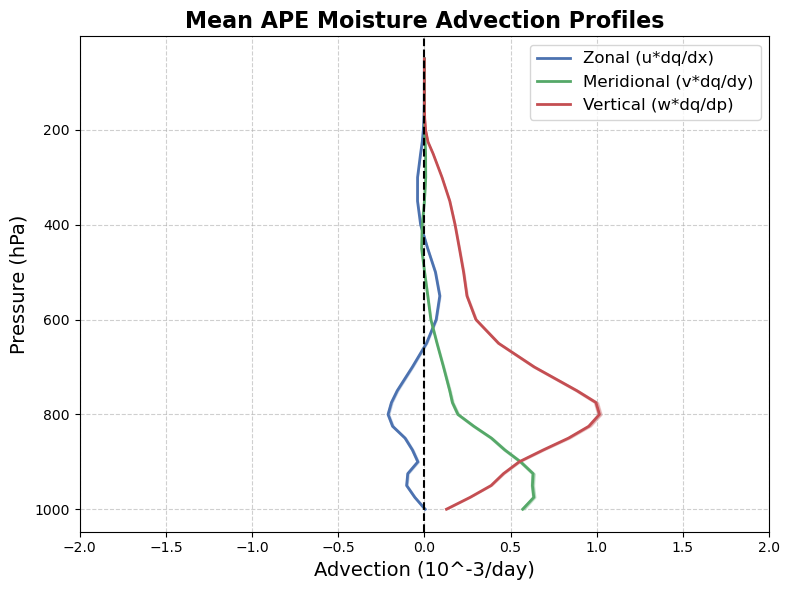

In [6]:
# Convert your lists of profiles to 2D NumPy arrays.

# Each array will have shape (n_samples, 29), where n_samples is the number of APE events.

_10_cubed_factor = 1000

cleaned_zonal_profiles = np.stack(apes['zonal_advection'].values) * _10_cubed_factor

cleaned_meridional_profiles = np.stack(apes['meridional_advection'].values) * _10_cubed_factor

cleaned_vertical_profiles = np.stack(apes['vertical_advection'].values) * _10_cubed_factor

# Compute the mean profile along the sample axis (axis=0), ignoring NaNs.

mean_zonal = np.nanmean(cleaned_zonal_profiles, axis=0) 

mean_merid = np.nanmean(cleaned_meridional_profiles, axis=0) 

mean_vertical = np.nanmean(cleaned_vertical_profiles, axis=0)

# Count non-NaN values per pressure level.

n_zonal = np.sum(~np.isnan(cleaned_zonal_profiles), axis=0)

n_merid = np.sum(~np.isnan(cleaned_meridional_profiles), axis=0)

n_vertical = np.sum(~np.isnan(cleaned_vertical_profiles), axis=0)

# Compute standard deviations ignoring NaNs.

std_zonal = np.nanstd(cleaned_zonal_profiles, axis=0, ddof=1)

std_merid = np.nanstd(cleaned_meridional_profiles, axis=0, ddof=1)

std_vertical = np.nanstd(cleaned_vertical_profiles, axis=0, ddof=1)

# Compute standard errors (be mindful that each level might have a different sample size).

se_zonal = std_zonal / np.sqrt(n_zonal)

se_merid = std_merid / np.sqrt(n_merid)

se_vertical = std_vertical / np.sqrt(n_vertical)

# Compute t-values per pressure level for a 95% confidence interval.
# For levels with less than 2 valid samples, we set the t-value to NaN.

t_zonal = np.array([t.ppf(0.975, df=int(n)-1) if n > 1 else np.nan for n in n_zonal])

t_merid = np.array([t.ppf(0.975, df=int(n)-1) if n > 1 else np.nan for n in n_merid])

t_vertical = np.array([t.ppf(0.975, df=int(n)-1) if n > 1 else np.nan for n in n_vertical])

# Compute the margin of error (CI = t * SE) for each level.

ci_zonal = t_zonal * se_zonal

ci_merid = t_merid * se_merid

ci_vertical = t_vertical * se_vertical

# Determine xlimit based on the maximum absolute value of (mean + CI) across all profiles.
max_val = np.max([np.abs(mean_zonal + ci_zonal),
                  np.abs(mean_merid + ci_merid),
                  np.abs(mean_vertical + ci_vertical)])

xlimit = np.ceil(max_val * 1.1)  # add 10% margin

# Define a custom color palette.

color_zonal = '#4C72B0'    # blue

color_merid = '#55A868'    # green

color_vertical = '#C44E52' # red

plt.figure(figsize=(8, 6))

# Plot the mean profiles with uncertainty bands using fill_betweenx.
plt.plot(mean_zonal, pressure, label='Zonal (u*dq/dx)', linewidth=2, color=color_zonal)

plt.fill_betweenx(pressure, mean_zonal - ci_zonal, mean_zonal + ci_zonal,
                  color=color_zonal, alpha=0.3)

plt.plot(mean_merid, pressure, label='Meridional (v*dq/dy)', linewidth=2, color=color_merid)

plt.fill_betweenx(pressure, mean_merid - ci_merid, mean_merid + ci_merid,
                  color=color_merid, alpha=0.3)

plt.plot(mean_vertical, pressure, label='Vertical (w*dq/dp)', linewidth=2, color=color_vertical)

plt.fill_betweenx(pressure, mean_vertical - ci_vertical, mean_vertical + ci_vertical,
                  color=color_vertical, alpha=0.3)

# Invert the y-axis so that pressure decreases upward.

plt.xlim(-xlimit, xlimit)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)

# Add labels, title, legend, and grid.
plt.xlabel('Advection (10^-3/day)', fontsize=14)

plt.ylabel('Pressure (hPa)', fontsize=14)

plt.title('Mean APE Moisture Advection Profiles', fontsize=16, fontweight='bold')

plt.legend(fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

plt.gca().invert_yaxis()

plt.show()

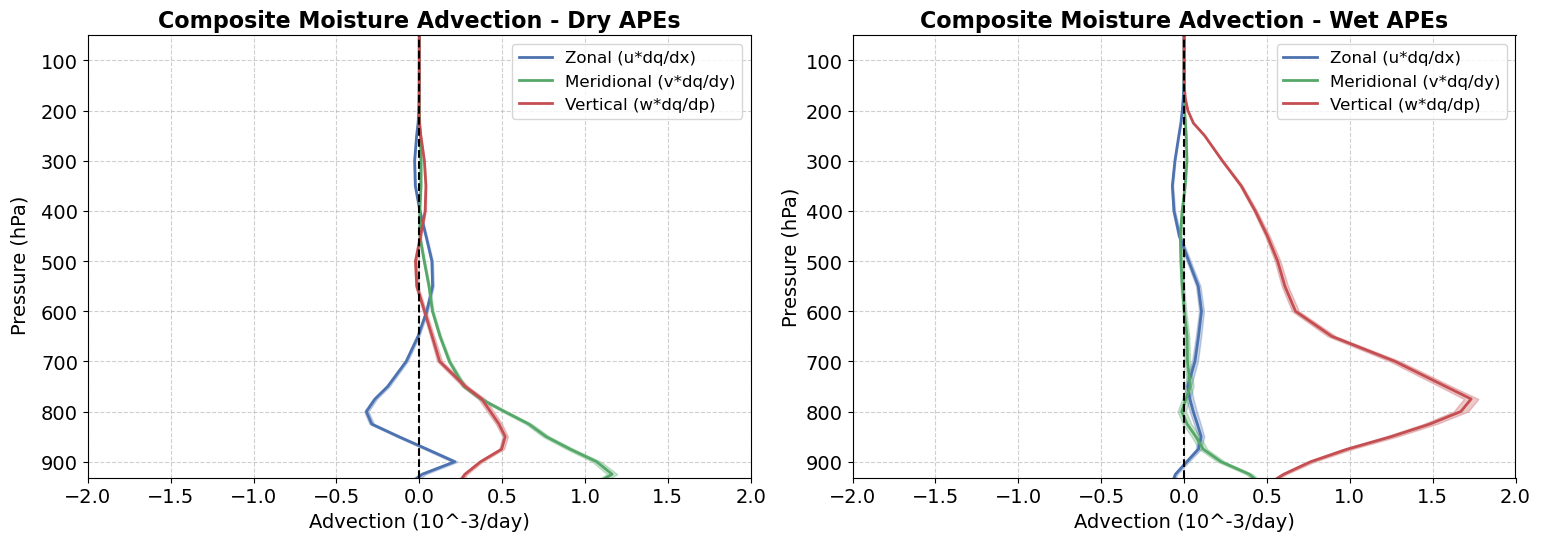

In [11]:
# -- Extract and convert profiles for dry and wet cases --

# Convert lists of profiles to 2D arrays (each of shape (n_samples, 29)).

# pressure = pressure / 100

mean_surface_pressure = master_clean['average_sp'].mean() / 100

dry_zonal = np.array(dryapes['zonal_advection'].tolist())

dry_merid = np.array(dryapes['meridional_advection'].tolist())

dry_vertical = np.array(dryapes['vertical_advection'].tolist())

wet_zonal = np.array(wetapes['zonal_advection'].tolist())

wet_merid = np.array(wetapes['meridional_advection'].tolist())

wet_vertical = np.array(wetapes['vertical_advection'].tolist())

# Global pressure array (assumed to be 1D with 29 levels)

# pressure = daily_avg['level'].data

# -- Function to compute mean and 95% CI using nanmean/nanstd --

def compute_stats(profiles):
    
    """
    profiles: 2D array of shape (n_samples, 29)
    Returns: mean (1D, 29) and margin of error (CI, 1D, 29)
    """
    
    _10_cubed_factor = 1000
    
    # Compute the mean ignoring NaNs.
    
    mean_profile = np.nanmean(profiles, axis=0)
    
    # Compute the number of valid (non-NaN) values per pressure level.
    n_vals = np.sum(~np.isnan(profiles), axis=0)
    
    # Compute standard error ignoring NaNs.
    se = np.nanstd(profiles, axis=0, ddof=1) / np.sqrt(n_vals)
    
    # Compute t-values per level; if less than 2 valid samples, return NaN.
    t_values = np.array([t.ppf(0.975, df=int(n)-1) if n > 1 else np.nan for n in n_vals])
    
    # Margin of error (95% confidence interval)
    ci = t_values * se
    
    return mean_profile * _10_cubed_factor, ci * _10_cubed_factor

# Compute statistics for dry apes_clean.

dry_mean_zonal, dry_ci_zonal = compute_stats(dry_zonal)

dry_mean_merid, dry_ci_merid = compute_stats(dry_merid) 

dry_mean_vertical, dry_ci_vertical = compute_stats(dry_vertical) 

# Compute statistics for wet apes_clean.

wet_mean_zonal, wet_ci_zonal = compute_stats(wet_zonal) 

wet_mean_merid, wet_ci_merid = compute_stats(wet_merid)

wet_mean_vertical, wet_ci_vertical = compute_stats(wet_vertical) 

# -- Determine symmetric x-axis limits for each subplot --
max_dry = np.max([np.abs(dry_mean_zonal + dry_ci_zonal),
                  np.abs(dry_mean_merid + dry_ci_merid),
                  np.abs(dry_mean_vertical + dry_ci_vertical)])
xlimit_dry = np.ceil(max_dry * 1.1)  # add 10% extra margin

max_wet = np.max([np.abs(wet_mean_zonal + wet_ci_zonal),
                  np.abs(wet_mean_merid + wet_ci_merid),
                  np.abs(wet_mean_vertical + wet_ci_vertical)])
xlimit_wet = np.ceil(max_wet * 1.1)

# -- Define a custom color palette --
color_zonal = '#4C72B0'    # blue
color_merid = '#55A868'    # green
color_vertical = '#C44E52' # red

# -- Create the figure with two subplots side by side --
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot for Dry apes_clean on ax1
ax1.plot(dry_mean_zonal, pressure, label='Zonal (u*dq/dx)', linewidth=2, color=color_zonal)

ax1.fill_betweenx(pressure, dry_mean_zonal - dry_ci_zonal, dry_mean_zonal + dry_ci_zonal,
                  color=color_zonal, alpha=0.3)

ax1.plot(dry_mean_merid, pressure, label='Meridional (v*dq/dy)', linewidth=2, color=color_merid)

ax1.fill_betweenx(pressure, dry_mean_merid - dry_ci_merid, dry_mean_merid + dry_ci_merid,
                  color=color_merid, alpha=0.3)

ax1.plot(dry_mean_vertical, pressure, label='Vertical (w*dq/dp)', linewidth=2, color=color_vertical)

ax1.fill_betweenx(pressure, dry_mean_vertical - dry_ci_vertical, dry_mean_vertical + dry_ci_vertical,
                  color=color_vertical, alpha=0.3)

ax1.set_ylim(pressure.min(), mean_surface_pressure_hPa)
ax1.invert_yaxis()
ax1.set_xlim(-xlimit_dry, xlimit_dry)
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Advection (10^-3/day)', fontsize=14)
ax1.set_title('Composite Moisture Advection - Dry APEs', fontsize=16, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=12)
ax1.tick_params(axis='both', labelsize=14)

# Plot for Wet apes_clean on ax2
ax2.plot(wet_mean_zonal, pressure, label='Zonal (u*dq/dx)', linewidth=2, color=color_zonal)

ax2.fill_betweenx(pressure, wet_mean_zonal - wet_ci_zonal, wet_mean_zonal + wet_ci_zonal,
                  color=color_zonal, alpha=0.3)

ax2.plot(wet_mean_merid, pressure, label='Meridional (v*dq/dy)', linewidth=2, color=color_merid)

ax2.fill_betweenx(pressure, wet_mean_merid - wet_ci_merid, wet_mean_merid + wet_ci_merid,
                  color=color_merid, alpha=0.3)

ax2.plot(wet_mean_vertical, pressure, label='Vertical (w*dq/dp)', linewidth=2, color=color_vertical)

ax2.fill_betweenx(pressure, wet_mean_vertical - wet_ci_vertical, wet_mean_vertical + wet_ci_vertical,
                  color=color_vertical, alpha=0.3)

ax2.set_ylim(pressure.min(), mean_surface_pressure)

ax2.invert_yaxis()

ax2.set_xlim(-xlimit_wet, xlimit_wet)

ax2.axvline(x=0, color='black', linestyle='--', linewidth=1.5)

ax2.set_xlabel('Advection (10^-3/day)', fontsize=14)

ax2.set_title('Composite Moisture Advection - Wet APEs', fontsize=16, fontweight='bold')

ax2.grid(True, linestyle='--', alpha=0.6)

ax2.legend(fontsize=12)

ax2.tick_params(axis='both', labelsize=14)

ax2.yaxis.set_tick_params(labelleft=True)

ax2.set_ylabel("Pressure (hPa)", fontsize=14)

# Common y-label for the figure

fig.text(0.04, 0.5, 'Pressure (hPa)', va='center', rotation='vertical', fontsize=14)

plt.tight_layout(rect=[0.05, 0.03, 1, 0.95])

plt.show()

In [32]:
with open("/home/annierosen16/master_clean.pkl", "wb") as file:
    
    pickle.dump(master_clean, file, protocol=pickle.HIGHEST_PROTOCOL)